# Stage 3 — LSTM (Long Short-Term Memory)

## What is an LSTM and why is it different?

In Stage 2, we used a **Feedforward Neural Network (FNN)**. The FNN treated each review as a **bag of words** — it had no sense of order. The sentence *"not good"* and *"good not"* would look identical to it.

An **LSTM** is a type of **Recurrent Neural Network (RNN)**. It reads text **word by word**, left to right, like a human. As it reads, it carries a **memory** (called the hidden state) that accumulates context from all the previous words. This lets it understand that *"not"* changes the meaning of *"good"* that follows.

### Key concepts you will see in this notebook:
- **Embedding layer**: Converts each word (integer ID) into a dense vector of numbers. Think of it as a lookup table where the model learns what each word "means".
- **LSTM layer**: Processes the sequence of word vectors one step at a time, updating its memory.
- **Bidirectional LSTM**: Reads the sequence both forwards AND backwards, then combines both views — this gives richer context.
- **Vocabulary & tokenization**: Instead of TF-IDF, we now give each unique word an integer ID (e.g. "good"→42, "bad"→17).

### Baseline to beat: **89.51%** (Logistic Regression, Stage 1)
### Previous result: *Run Stage 2 first and note your FNN accuracy here.*

---

### Imports

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, precision_score, recall_score,
    f1_score, roc_curve, auc
)

print("All imports successful.")

All imports successful.


### Set Device (GPU/CPU)

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


---
## Step 1 — Load & Clean Data

We do light text cleaning before tokenization:
- Remove HTML tags (the IMDb dataset has some `<br />` tags)
- Lowercase everything
- Keep only letters and spaces (remove punctuation/numbers)

This helps the vocabulary stay clean so the model learns better word meanings.

In [3]:
df = pd.read_csv('../data/IMDB Dataset.csv')
df['sentiment'] = df['sentiment'].map({'positive': 1, 'negative': 0})

def clean_text(text):
    """Remove HTML tags, lowercase, keep only letters."""
    text = re.sub(r'<[^>]+>', ' ', text)   # remove HTML tags like <br />
    text = text.lower()                     # lowercase
    text = re.sub(r'[^a-z\s]', ' ', text)  # keep only letters and spaces
    text = re.sub(r'\s+', ' ', text).strip() # collapse multiple spaces
    return text

df['clean_review'] = df['review'].apply(clean_text)

print(f"Dataset shape: {df.shape}")
print(f"\nOriginal review:\n{df['review'].iloc[0][:200]}")
print(f"\nCleaned review:\n{df['clean_review'].iloc[0][:200]}")

Dataset shape: (50000, 3)

Original review:
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me abo

Cleaned review:
one of the other reviewers has mentioned that after watching just oz episode you ll be hooked they are right as this is exactly what happened with me the first thing that struck me about oz was its br


---
## Step 2 — Build Vocabulary

A **vocabulary** is a dictionary that maps every unique word to an integer ID.
For example: `{"the": 1, "movie": 2, "great": 3, ...}`

We only keep the top `VOCAB_SIZE` most frequent words. Rare words (typos, names) would just add noise.

Two special tokens:
- `<PAD>` (index 0): used to pad short reviews so all reviews are the same length
- `<UNK>` (index 1): used for words not in our vocabulary

In [4]:
VOCAB_SIZE  = 20000   # keep the 20,000 most common words
MAX_LEN     = 200     # truncate / pad every review to 200 words

# Count word frequencies across ALL reviews
all_words = []
for review in df['clean_review']:
    all_words.extend(review.split())

word_counts = Counter(all_words)
print(f"Total unique words in corpus: {len(word_counts):,}")

# Keep only the top VOCAB_SIZE words
most_common = word_counts.most_common(VOCAB_SIZE)

# word2idx: maps word → integer ID
# We reserve 0 for <PAD> and 1 for <UNK>
word2idx = {'<PAD>': 0, '<UNK>': 1}
for rank, (word, _) in enumerate(most_common, start=2):
    word2idx[word] = rank

print(f"Vocabulary size (including special tokens): {len(word2idx):,}")
print(f"Sample entries: { {k: word2idx[k] for k in list(word2idx)[:8]} }")

Total unique words in corpus: 99,420
Vocabulary size (including special tokens): 20,002
Sample entries: {'<PAD>': 0, '<UNK>': 1, 'the': 2, 'and': 3, 'a': 4, 'of': 5, 'to': 6, 'is': 7}


---
## Step 3 — Tokenize & Pad Reviews

Now we convert each cleaned review from a string into a list of integers, then ensure every list is exactly `MAX_LEN` long:
- If a review is **longer** than MAX_LEN → **truncate** (cut off the end)
- If a review is **shorter** than MAX_LEN → **pad** with zeros on the right

In [5]:
def tokenize_and_pad(review, word2idx, max_len):
    """Convert a review string into a padded list of integer IDs."""
    tokens = review.split()
    # Map each word to its ID (use 1 = <UNK> if word not in vocabulary)
    ids = [word2idx.get(word, 1) for word in tokens]
    # Truncate if too long
    ids = ids[:max_len]
    # Pad with zeros if too short
    ids += [0] * (max_len - len(ids))
    return ids

X = np.array([tokenize_and_pad(r, word2idx, MAX_LEN) for r in df['clean_review']])
y = df['sentiment'].values

print(f"X shape: {X.shape}  (50,000 reviews × {MAX_LEN} token IDs each)")
print(f"y shape: {y.shape}")
print(f"\nFirst review as token IDs (first 20): {X[0][:20]}")

X shape: (50000, 200)  (50,000 reviews × 200 token IDs each)
y shape: (50000,)

First review as token IDs (first 20): [  29    5    2   78 2038   47 1052   12  101  150   42 3057  395   21
  230   30 3174   33   26  205]


---
## Step 4 — Train / Test Split & PyTorch Dataset

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train: {X_train.shape[0]} samples")
print(f"Test:  {X_test.shape[0]} samples")

class IMDbDataset(Dataset):
    """
    Custom PyTorch Dataset.
    __len__  → tells DataLoader how many samples exist
    __getitem__ → returns one (X, y) pair at index i
    """
    def __init__(self, X, y):
        self.X = torch.LongTensor(X)    # LongTensor for integer indices
        self.y = torch.FloatTensor(y)   # FloatTensor for binary labels

    def __len__(self):
        return len(self.y)

    def __getitem__(self, i):
        return self.X[i], self.y[i]

BATCH_SIZE = 64

train_loader = DataLoader(IMDbDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(IMDbDataset(X_test,  y_test),  batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches: {len(train_loader)}")
print(f"Test  batches: {len(test_loader)}")

Train: 40000 samples
Test:  10000 samples
Train batches: 625
Test  batches: 157


---
## Step 5 — Define the LSTM Model

Here is what happens inside the model, layer by layer:

1. **Embedding(VOCAB_SIZE+2, EMBED_DIM)**: Takes each integer word ID and looks up a vector of 128 numbers for it. The model *learns* these vectors during training — words that appear in similar contexts end up with similar vectors.

2. **LSTM(EMBED_DIM, HIDDEN_DIM, bidirectional=True)**: Reads the sequence of 128-dim word vectors. Because it's bidirectional, it reads both left→right and right→left. The output at each time step has size `HIDDEN_DIM * 2` (both directions concatenated).

3. **We take only the final hidden state** (the last step's memory). This is a summary of the entire review.

4. **Dropout + Linear + Sigmoid**: Same as Stage 2 — regularize, project to a single number, squash to [0,1].

In [7]:
EMBED_DIM  = 128   # each word is represented as a 128-dimensional vector
HIDDEN_DIM = 256   # LSTM hidden state size (each direction)
N_LAYERS   = 2     # stack 2 LSTM layers for more capacity
DROPOUT    = 0.3

class SentimentLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, n_layers, dropout):
        super(SentimentLSTM, self).__init__()

        # Embedding: integer word IDs → dense vectors
        # padding_idx=0 tells PyTorch to keep the <PAD> vector as all-zeros
        self.embedding = nn.Embedding(
            vocab_size + 2, embed_dim, padding_idx=0
        )

        # Bidirectional LSTM
        self.lstm = nn.LSTM(
            input_size  = embed_dim,
            hidden_size = hidden_dim,
            num_layers  = n_layers,
            batch_first = True,      # input shape: (batch, seq_len, embed_dim)
            bidirectional = True,    # read forward AND backward
            dropout = dropout if n_layers > 1 else 0.0
        )

        self.dropout = nn.Dropout(dropout)

        # *2 because bidirectional concatenates forward + backward hidden states
        self.fc = nn.Linear(hidden_dim * 2, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # x shape: (batch_size, seq_len)
        embedded = self.dropout(self.embedding(x))
        # embedded shape: (batch_size, seq_len, embed_dim)

        lstm_out, (hidden, cell) = self.lstm(embedded)
        # hidden shape: (n_layers * 2, batch_size, hidden_dim)
        # We want the last layer's forward and backward hidden states

        # hidden[-2] = last forward layer, hidden[-1] = last backward layer
        last_hidden = torch.cat((hidden[-2], hidden[-1]), dim=1)
        # last_hidden shape: (batch_size, hidden_dim * 2)

        out = self.dropout(last_hidden)
        out = self.fc(out)       # (batch_size, 1)
        out = self.sigmoid(out)  # squeeze probabilities to [0, 1]
        return out.squeeze()     # (batch_size,)


model = SentimentLSTM(
    vocab_size = VOCAB_SIZE,
    embed_dim  = EMBED_DIM,
    hidden_dim = HIDDEN_DIM,
    n_layers   = N_LAYERS,
    dropout    = DROPOUT
).to(device)

print(model)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal trainable parameters: {total_params:,}")

SentimentLSTM(
  (embedding): Embedding(20002, 128, padding_idx=0)
  (lstm): LSTM(128, 256, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=512, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)

Total trainable parameters: 4,928,257


---
## Step 6 — Loss, Optimizer & Scheduler

In [8]:
criterion = nn.BCELoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=2,
    verbose=True
)

print("Criterion, optimizer and scheduler ready.")

Criterion, optimizer and scheduler ready.


c:\Users\manos\Desktop\PROJECTS\sentiment-analyzer\venv\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


---
## Step 7 — Early Stopping

Same class as Stage 2 — stops training when validation loss stops improving and restores the best weights.

In [9]:
class EarlyStopping:
    def __init__(self, patience=5, min_delta=1e-4):
        self.patience   = patience
        self.min_delta  = min_delta
        self.counter    = 0
        self.best_loss  = float('inf')
        self.best_state = None

    def step(self, val_loss, model):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss  = val_loss
            self.counter    = 0
            self.best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            self.counter += 1
        return self.counter >= self.patience

    def restore(self, model):
        if self.best_state:
            model.load_state_dict(self.best_state)
            print(f"Restored best weights (val_loss={self.best_loss:.4f})")

early_stopping = EarlyStopping(patience=5)
print("EarlyStopping ready.")

EarlyStopping ready.


---
## Step 8 — Training & Evaluation Functions

In [10]:
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        preds = model(X_batch)
        loss  = criterion(preds, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item() * len(y_batch)
        correct    += ((preds >= 0.5) == y_batch).sum().item()
        total      += len(y_batch)

    return total_loss / total, correct / total


def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss  = 0.0
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            probs = model(X_batch)
            total_loss += criterion(probs, y_batch).item() * len(y_batch)
            all_probs.extend(probs.cpu().numpy())
            all_preds.extend((probs >= 0.5).cpu().numpy().astype(int))
            all_labels.extend(y_batch.cpu().numpy().astype(int))

    n = len(all_labels)
    metrics = {
        'loss':      total_loss / n,
        'accuracy':  accuracy_score(all_labels, all_preds),
        'precision': precision_score(all_labels, all_preds),
        'recall':    recall_score(all_labels, all_preds),
        'f1':        f1_score(all_labels, all_preds),
    }
    return metrics, all_preds, all_labels, all_probs

print("train_epoch and eval_epoch functions defined.")

train_epoch and eval_epoch functions defined.


---
## Step 9 — Training Loop

⚠️ **Heads up**: The LSTM is significantly larger than the FNN. Training will take longer — roughly 3–8 minutes per epoch on a GTX 1060. With early stopping at patience=5 you are unlikely to exceed 15 epochs.

In [11]:
EPOCHS = 20

history = {
    'train_loss': [], 'val_loss': [],
    'train_acc':  [], 'val_acc':  [],
    'val_f1':     []
}

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc    = train_epoch(model, train_loader, criterion, optimizer)
    val_metrics, _, _, _     = eval_epoch(model, test_loader, criterion)

    scheduler.step(val_metrics['loss'])

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_metrics['loss'])
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_metrics['accuracy'])
    history['val_f1'].append(val_metrics['f1'])

    print(
        f"Epoch {epoch:02d}/{EPOCHS}  "
        f"train_loss={train_loss:.4f}  "
        f"val_loss={val_metrics['loss']:.4f}  "
        f"val_acc={val_metrics['accuracy']:.4f}  "
        f"f1={val_metrics['f1']:.4f}"
    )

    if early_stopping.step(val_metrics['loss'], model):
        print(f"\nEarly stopping triggered at epoch {epoch}.")
        break

early_stopping.restore(model)

Epoch 01/20  train_loss=0.6517  val_loss=0.6249  val_acc=0.6351  f1=0.5048
Epoch 02/20  train_loss=0.5674  val_loss=0.4667  val_acc=0.8027  f1=0.8232
Epoch 03/20  train_loss=0.3950  val_loss=0.3278  val_acc=0.8539  f1=0.8571
Epoch 04/20  train_loss=0.3195  val_loss=0.2993  val_acc=0.8716  f1=0.8769
Epoch 05/20  train_loss=0.2730  val_loss=0.2855  val_acc=0.8824  f1=0.8870
Epoch 06/20  train_loss=0.2384  val_loss=0.2960  val_acc=0.8782  f1=0.8736
Epoch 07/20  train_loss=0.2089  val_loss=0.3038  val_acc=0.8851  f1=0.8908
Epoch 08/20  train_loss=0.1805  val_loss=0.2849  val_acc=0.8881  f1=0.8913
Epoch 09/20  train_loss=0.1519  val_loss=0.3080  val_acc=0.8924  f1=0.8956
Epoch 10/20  train_loss=0.1298  val_loss=0.3199  val_acc=0.8927  f1=0.8946
Epoch 11/20  train_loss=0.1109  val_loss=0.3490  val_acc=0.8864  f1=0.8906
Epoch 12/20  train_loss=0.0801  val_loss=0.3745  val_acc=0.8894  f1=0.8932
Epoch 13/20  train_loss=0.0691  val_loss=0.4005  val_acc=0.8879  f1=0.8909

Early stopping triggered

---
## Step 10 — Training Curves

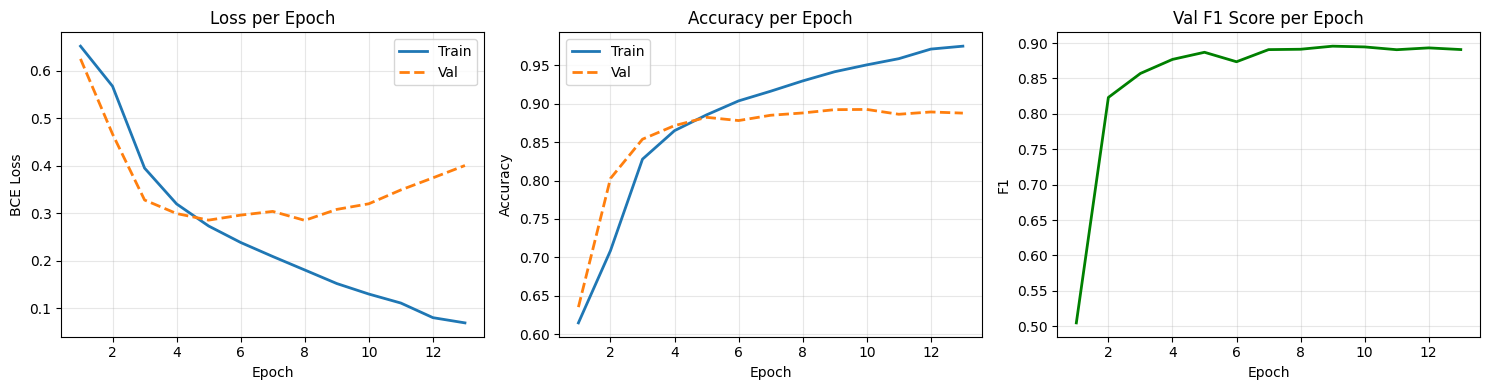

In [12]:
epochs_ran = range(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(epochs_ran, history['train_loss'], label='Train', linewidth=2)
axes[0].plot(epochs_ran, history['val_loss'],   label='Val',   linewidth=2, linestyle='--')
axes[0].set_title('Loss per Epoch'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('BCE Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs_ran, history['train_acc'], label='Train', linewidth=2)
axes[1].plot(epochs_ran, history['val_acc'],   label='Val',   linewidth=2, linestyle='--')
axes[1].set_title('Accuracy per Epoch'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(epochs_ran, history['val_f1'], color='green', linewidth=2)
axes[2].set_title('Val F1 Score per Epoch'); axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('F1')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves_lstm.png', dpi=150)
plt.show()

---
## Step 11 — Final Test Evaluation

In [13]:
final_metrics, y_pred, y_true, y_probs = eval_epoch(model, test_loader, criterion)

print("── Final Test Metrics ─────────────────────────────")
for k, v in final_metrics.items():
    print(f"  {k:<12}: {v:.4f}")

print("\n── Classification Report ──────────────────────────")
print(classification_report(y_true, y_pred, target_names=['Negative', 'Positive']))

── Final Test Metrics ─────────────────────────────
  loss        : 0.2849
  accuracy    : 0.8881
  precision   : 0.8730
  recall      : 0.9103
  f1          : 0.8913

── Classification Report ──────────────────────────
              precision    recall  f1-score   support

    Negative       0.90      0.87      0.88      4961
    Positive       0.87      0.91      0.89      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



---
## Step 12 — Confusion Matrix

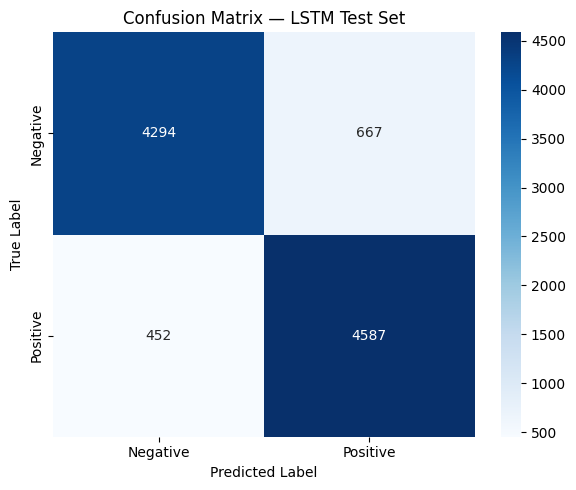

TN=4294  FP=667  FN=452  TP=4587


In [14]:
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Negative', 'Positive'],
    yticklabels=['Negative', 'Positive'],
    ax=ax
)
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
ax.set_title('Confusion Matrix — LSTM Test Set')
plt.tight_layout()
plt.savefig('confusion_matrix_lstm.png', dpi=150)
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"TN={tn}  FP={fp}  FN={fn}  TP={tp}")

---
## Step 13 — ROC Curve & AUC

Optimal decision threshold: 0.531
AUC: 0.9554


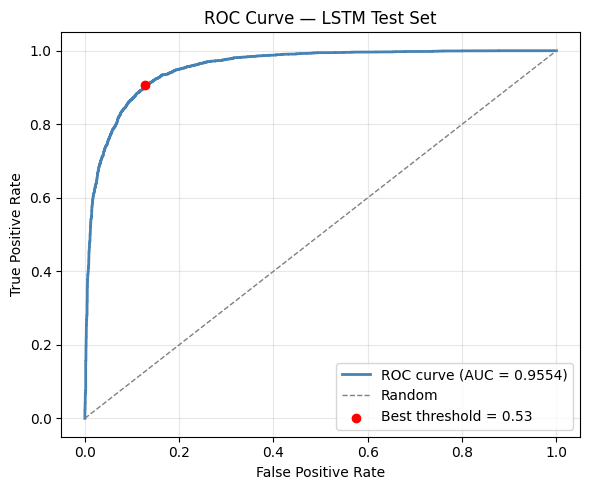

In [15]:
fpr, tpr, thresholds = roc_curve(y_true, y_probs)
roc_auc = auc(fpr, tpr)

best_idx    = np.argmax(tpr - fpr)
best_thresh = thresholds[best_idx]
print(f"Optimal decision threshold: {best_thresh:.3f}")
print(f"AUC: {roc_auc:.4f}")

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color='steelblue', linewidth=2,
        label=f'ROC curve (AUC = {roc_auc:.4f})')
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1, label='Random')
ax.scatter(fpr[best_idx], tpr[best_idx], color='red', zorder=5,
           label=f'Best threshold = {best_thresh:.2f}')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — LSTM Test Set')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve_lstm.png', dpi=150)
plt.show()

---
## Step 14 — Inference on Custom Text

In [16]:
def predict_sentiment(review_text: str, threshold: float = 0.5) -> dict:
    """
    Predict sentiment for a single raw review string using the LSTM model.
    """
    model.eval()
    cleaned = clean_text(review_text)
    ids = tokenize_and_pad(cleaned, word2idx, MAX_LEN)
    tensor = torch.LongTensor([ids]).to(device)  # shape: (1, MAX_LEN)

    with torch.no_grad():
        prob = model(tensor).item()

    label = 'Positive' if prob >= threshold else 'Negative'
    conf  = prob if prob >= threshold else 1 - prob
    return {'label': label, 'probability': round(prob, 4), 'confidence': round(conf, 4)}


samples = [
    "This movie was absolutely fantastic! The acting was superb.",
    "Terrible film. Waste of two hours. The plot made no sense at all.",
    "It was okay, nothing special but not bad either."
]

for text in samples:
    result = predict_sentiment(text)
    print(f"[{result['label']}] (p={result['probability']}, conf={result['confidence']})")
    print(f"  → {text[:70]}...\n")

[Positive] (p=0.9969, conf=0.9969)
  → This movie was absolutely fantastic! The acting was superb....

[Negative] (p=0.001, conf=0.999)
  → Terrible film. Waste of two hours. The plot made no sense at all....

[Negative] (p=0.0409, conf=0.9591)
  → It was okay, nothing special but not bad either....



---
## Step 15 — Save Model

In [17]:
torch.save(model.state_dict(), 'sentiment_model_lstm.pt')
print("Model saved → sentiment_model_lstm.pt")

# To reload later:
# loaded_model = SentimentLSTM(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, N_LAYERS, DROPOUT).to(device)
# loaded_model.load_state_dict(torch.load('sentiment_model_lstm.pt'))
# loaded_model.eval()

Model saved → sentiment_model_lstm.pt
